# Tangram Probability Filtering (Broad Cell Types)

**Purpose:** Turn raw per-cell Tangram cell-type probability scores into
final `pred_cell_types` labels, filter out low-confidence ("undetermined")
cells, cross-reference against a Banksy spatial-domain clustering, and pull
marker genes for a few clusters of interest.

**Pipeline:**
1. For each sample: load its concatenated per-patch Tangram probability
   scores, clip/rescale them (`create_tangram_scores_df`), and assign each
   cell the cell type with the highest scaled score above `threshold`
   (`determine_cell_type` / `add_celltype_predictions`); cells below
   threshold are labeled `"undetermined"` and dropped. Saves before/after
   cell-type-count tables, score-distribution histograms, spatial plots, and
   the final filtered `.h5ad` per sample.
2. Cross-references the `0.5`-threshold Tangram output against a Banksy
   spatial-domain-clustered object (`adata_scaled_gaussian.h5ad`), subsetting
   both to their common cells and copying `pred_cell_types` onto the Banksy
   object.
3. Plots a stacked bar chart of cell-type proportions per Banksy cluster,
   then pulls rank-genes marker genes and previews a few individual markers
   spatially for clusters 2, 6, and 7 (candidate senescent/NPC populations).

**Cleanup notes (this pass):** consolidated imports that were scattered
and duplicated across many cells (including one, `seaborn`, that was
actually used *before* its own import cell -- a real ordering bug that would
error on a fresh run); removed three `.h5ad`/bare-variable cells positioned
*before* the sample loop that only worked because `patdir` / `adata_pred_filt`
happened to be left over as globals from a previous out-of-order run in the
same kernel (not reproducible on a fresh run, and one used the wrong file
extension, `.txt`, for an `.h5ad` write); removed a `threshold_values` list
that turned out to be dead -- the loop was written to iterate over it
(`#for threshold in threshold_values:` is still there, commented out) but
was switched at some point to just use a single hardcoded `threshold`
instead; and removed a number of duplicate bare-variable-display debugging
cells. Function/loop logic that produces saved outputs is unchanged.

In [8]:
import glob
import os

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)


## Helper functions

In [9]:
def create_tangram_scores_df(inp_path, samp_nm, outdir):
    """
    Load and combine all per-patch Tangram probability-score files for one
    sample, then clip/rescale them and save raw + scaled score-distribution
    histograms.

    Returns the scaled (0-1 rescaled per cell type) scores DataFrame.
    """
    directory_path = f"{inp_path}{samp_nm}/tangram_runs/post_pred/"
    file_paths = glob.glob(os.path.join(directory_path, '*_prob_scores.txt'))

    df_plot = pd.concat((pd.read_csv(file, sep='\t', index_col=0) for file in file_paths))

    constructed_df_unscaled = create_constructed_df(df_plot, perc=0.02, scale=False)
    plot_tangram_score_dist(constructed_df_unscaled, outdir, file_name="tangram_scores_raw")

    constructed_df_scaled = create_constructed_df(df_plot, perc=0.02, scale=True)
    plot_tangram_score_dist(constructed_df_scaled, outdir, file_name="tangram_scores_scaled")

    return constructed_df_scaled


In [10]:
def create_constructed_df(df_plot, perc=0, scale=False):
    """Clip each column to its [perc, 1-perc] quantile range, optionally
    followed by min-max rescaling to [0, 1]."""
    df_clipped = df_plot.clip(df_plot.quantile(perc), df_plot.quantile(1 - perc), axis=1)

    if scale:
        df_normalized = (df_clipped - df_clipped.min()) / (df_clipped.max() - df_clipped.min())
        print(df_normalized.head())
        return df_normalized
    else:
        print(df_clipped.head())
        return df_clipped


def assign_and_count_cell_types(df_normalized):
    """Assign each row (cell) the column (cell type) with the max value,
    and count how many cells fall into each cell type.

    Not currently called anywhere in this notebook; kept as a small utility
    for ad hoc checks (see the commented example below).
    """
    max_prob_cell_type = df_normalized.idxmax(axis=1)
    counts = max_prob_cell_type.value_counts()
    return counts

# Example usage:
# df_plot = ad_sp.obsm["tangram_ct_pred"][annotation_list]
# constructed_df = create_constructed_df(df_plot, perc=0.02)  # Use perc=0.02 to match the plot
# cell_type_counts = assign_and_count_cell_types(constructed_df)


In [11]:
def plot_tangram_score_dist(tangram_score_df, outdir, file_name):
    """Save one histogram per column (cell type) of `tangram_score_df` into a
    single multi-page PDF."""
    with PdfPages(f"{outdir}/{file_name}.pdf") as pdf:
        for col in tangram_score_df.columns:
            fig = plt.figure(figsize=(8, 6))
            plt.hist(tangram_score_df[col], bins=50, color='skyblue', edgecolor='black')
            plt.title(f'Histogram of {col}')
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.legend()

            pdf.savefig(fig)
            plt.close(fig)


In [12]:
def determine_cell_type(row, threshold):
    """Return the cell type (column name) with the highest score in `row`,
    or "undetermined" if that max score doesn't clear `threshold`."""
    max_value = row.max()
    top_values = row.nlargest(2)

    if max_value <= threshold:
        return 'undetermined'
    else:
        return top_values.idxmax()


In [13]:
def add_celltype_predictions(adata, tangram_scaled_scores, threshold):
    """Assign `pred_cell_types` to each cell in `adata.obs`, based on
    `tangram_scaled_scores` and the given confidence `threshold`."""
    tangram_scaled_scores['pred_cell_types'] = tangram_scaled_scores.apply(determine_cell_type, axis=1, threshold=threshold)
    constructed_df_col = tangram_scaled_scores['pred_cell_types']
    constructed_df_col.index = constructed_df_col.index.astype(str)

    adata.obs['pred_cell_types'] = constructed_df_col.reindex(adata.obs.index)
    return adata


In [14]:
def save_celltype_counts_to_pdf_matplotlib(adata, column_name, output_dir, file_name, cutoff=None):
    """
    Save a one-page PDF table of cell-type counts and percentages from an
    AnnData object.

    Parameters
    ----------
    adata : AnnData
    column_name : str
        Column in `adata.obs` holding cell-type labels.
    output_dir : str
        Directory to save the PDF into.
    file_name : str
        Output file name (without extension).
    cutoff : optional
        Unused directly here (was previously used to name the output file
        based on threshold; the file name is now always `file_name` as
        passed by the caller). Kept as a parameter for backward
        compatibility with existing call sites.

    Returns
    -------
    output_pdf_path : str
    """
    if column_name not in adata.obs.columns:
        raise ValueError(f"'{column_name}' not found in adata.obs.columns")

    os.makedirs(output_dir, exist_ok=True)

    value_counts = adata.obs[column_name].value_counts()
    df = value_counts.reset_index()
    df.columns = ['Cell Type', 'Count']
    total_counts = df['Count'].sum()
    df['Percentage'] = (df['Count'] / total_counts * 100).round(2)

    output_pdf_path = os.path.join(output_dir, f"{file_name}.pdf")
    with PdfPages(output_pdf_path) as pdf:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.axis('tight')
        ax.axis('off')

        title = f"Cell Type Counts and Percentages (Total Cells: {total_counts})"
        plt.text(0.5, 1.1, title, ha='center', fontsize=14, transform=ax.transAxes)

        table = ax.table(
            cellText=df.values,
            colLabels=df.columns,
            loc='center',
            cellLoc='center',
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.auto_set_column_width(col=list(range(len(df.columns))))

        pdf.savefig(fig)
        plt.close(fig)

    print(f"PDF saved to {output_pdf_path}")
    return output_pdf_path


In [15]:
def plot_spatial(adata, outdir, file_name, threshold=None):
    """Save a spatial plot of `bin_count` for `adata` to `outdir/file_name.pdf`.

    `threshold` is unused directly (kept for backward compatibility with
    existing call sites, which pass it just to record it in their own
    surrounding code).
    """
    spa_fig_filt = f"{outdir}/{file_name}.pdf"
    sc.pl.spatial(adata, color='bin_count', show=False, size=2, img_key=None)
    plt.savefig(spa_fig_filt)


## Configuration

**Sample-list toggle:** three candidate sample lists are defined in sequence below; only the last one assigned to `samps` (cell defining `['HL20221019_broad_no_mast_filt', 'HL180801_filt']`) is what the loop further down actually uses. The earlier two are kept, commented/plain, as a record of other sample groupings used in prior runs -- edit which one is active as needed.

In [24]:
# samps = ['HL20221019_broad_no_mast_filt']

# 'HL180801_filt' / JL_101_2_3 not in the deep-sequencing batch
samps = ['HL180809_filt', 'HL230324_filt', 'HL230325_filt']
# samps = ['HL160029_filt', 'HL180809_filt', 'HL230324_filt', 'HL230325_filt']


In [1]:
samps = ['HL170058_filt']


In [4]:
# JL_101 and QY_2480 (this is the sample list actually used below)
samps = ['HL20221019_broad_no_mast_filt', 'HL180801_filt']


**Input-directory toggle:** similarly, `idir` is set twice -- the second value (for samples that were *not* deep-sequenced, matching the sample list above) is the one in effect below.

In [2]:
# idir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/tangram/deep_seq/'


In [5]:
# idir for JL_101 and QY_2480 (were not deep-sequenced) -- this is the value in effect
idir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/tangram/'


In [6]:
odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/'

In [7]:
# Confidence threshold below which a cell is labeled "undetermined" (see
# determine_cell_type). NOTE: this single threshold is what's actually used
# by the loop below -- a `threshold_values` list existed at one point for
# scanning multiple cutoffs, but the loop's inner `for threshold in
# threshold_values:` was disabled in favor of this single hardcoded value
# (that dead loop line is still visible, commented out, inside the loop below).
threshold = 0.5


## Score, label, and filter each sample by Tangram confidence

HL20221019_broad_no_mast_filt
AnnData object with n_obs × n_vars = 316805 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj'
    uns: 'celltype_proj_colors', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL20221019_broad_no_mast_filt
        Hepatocytes   Myeloid  Cholangiocyte       HSC  Endothelial         B  \
284707     0.000396  0.202244       0.000112  1.052163     1.330599  0.049025   
284708     0.000484  0.607737       0.000118  1.135747     0.000254  0.000080   
284710     1.426139  0.000371       0.000238  0.000343     0.292037  0.012877   
284711     0.000448  0.682274       0.000096  0.733982     0.685281  0.000060   
284712     0.000516  0.531532       0.208824  0.385758     0.692230  0.

/tmp/ipykernel_1542267/1956570501.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


true
        Hepatocytes   Myeloid  Cholangiocyte       HSC  Endothelial         B  \
284707     0.000000  0.157746       0.000062  0.926393     0.947798  0.150551   
284708     0.000046  0.474302       0.000078  1.000000     0.000040  0.000103   
284710     0.750236  0.000150       0.000390  0.000124     0.207910  0.039438   
284711     0.000027  0.532491       0.000020  0.646192     0.488063  0.000042   
284712     0.000063  0.414812       0.541656  0.339533     0.493014  0.453514   

            T_NK  
284707  0.163827  
284708  0.438431  
284710  0.100745  
284711  0.060888  
284712  0.409808  


/tmp/ipykernel_1542267/1956570501.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Plotting spatial original
0.5
AnnData object with n_obs × n_vars = 316805 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'celltype_proj_colors', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
Saving celltype propotions before cutoff applied
cts_before_0.5
PDF saved to /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL20221019_broad_no_mast_filt/cts_before_0.5.pdf
View of AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'celltype_proj_colors', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatia

...

true
        Hepatocytes   Myeloid  Cholangiocyte  Endothelial       HSC      T_NK  \
160583     0.489171  0.156766       0.235776     0.343605  0.144585  0.084010   
160584     0.384839  0.193934       0.144280     0.067939  0.917981  0.119739   
160585     0.533809  0.156545       0.129167     0.000284  0.453036  0.198898   
160586     0.488938  0.204916       0.117336     0.200442  0.102373  0.118548   
160587     0.505521  0.134417       0.223637     0.171996  0.154023  0.084607   

               B  
160583  0.054697  
160584  0.272165  
160585  0.080064  
160586  0.002456  
160587  0.135368  


/tmp/ipykernel_1542267/1956570501.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Plotting spatial original
0.5
AnnData object with n_obs × n_vars = 420828 × 17497
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'celltype_proj_colors', 'spatial'
    obsm: 'spatial', 'spatial_cropped', 'tangram_ct_pred'
Saving celltype propotions before cutoff applied
cts_before_0.5
PDF saved to /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL180801_filt/cts_before_0.5.pdf
View of AnnData object with n_obs × n_vars = 283669 × 17497
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'celltype_proj_colors', 'spatial'
    obsm: 'spatial', 'spatial_cropped', 'tangram_ct_pred'
Saving celltype propotions when cutoff applied
PDF saved to /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tan

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Saving object


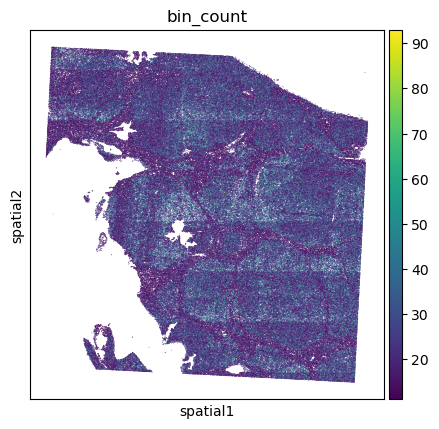

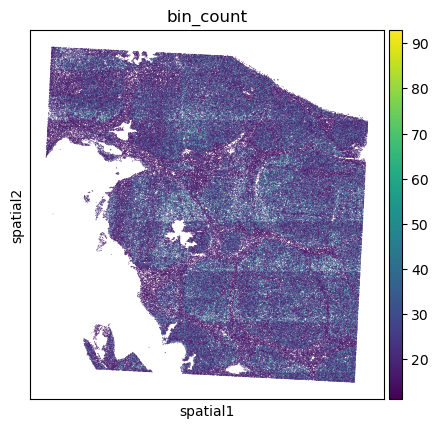

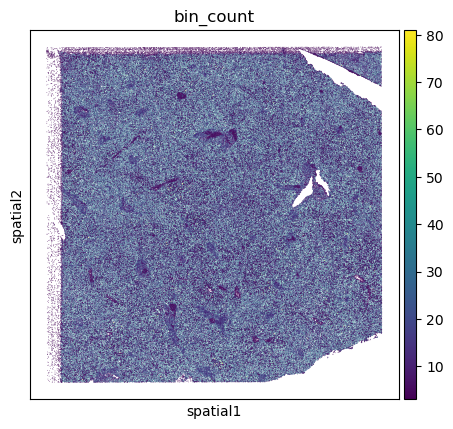

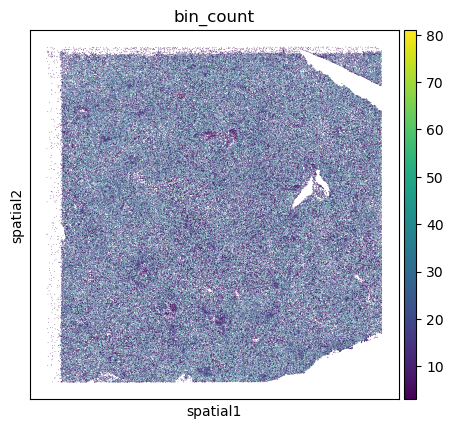

In [16]:
for sample_nm in samps:
    print(sample_nm)
    ad_sp = sc.read_h5ad(f"{idir}{sample_nm}/merge/Post_sp_ct_proj_comb_outer.h5ad")  # after b2c filtering
    print(ad_sp)

    patdir = f"{odir}{sample_nm}"
    print(patdir)
    os.makedirs(patdir, exist_ok=True)

    constructed_df = create_tangram_scores_df(idir, sample_nm, patdir)

    print("Plotting spatial original")
    plot_spatial(ad_sp, patdir, file_name="spatial_orig")

    constructed_df_cp = constructed_df.copy()

    print(threshold)
    if 'pred_cell_types' in constructed_df_cp.columns:
        print("dropping col")
        constructed_df_cp.drop(columns=['pred_cell_types'], inplace=True)
    adata_pred = add_celltype_predictions(ad_sp, constructed_df_cp, threshold=threshold)
    print(adata_pred)

    # Cell-type proportions before dropping "undetermined" cells.
    print("Saving celltype propotions before cutoff applied")
    fn_before = f"cts_before_{threshold}"
    print(fn_before)
    save_celltype_counts_to_pdf_matplotlib(adata_pred, "pred_cell_types", patdir, file_name=fn_before)
    adata_pred_filt = adata_pred[~adata_pred.obs['pred_cell_types'].isin(['undetermined'])]
    print(adata_pred_filt)

    # Cell-type proportions after dropping "undetermined" cells.
    print("Saving celltype propotions when cutoff applied")
    fn_after = f"cts_after_{threshold}"
    save_celltype_counts_to_pdf_matplotlib(adata_pred_filt, "pred_cell_types", patdir, file_name=fn_after, cutoff=str(threshold))

    print("Plotting spatial")
    sp_after = f"spatial_{threshold}_after"
    plot_spatial(adata_pred_filt, patdir, file_name=sp_after, threshold=str(threshold))

    print("Saving object")
    adata_pred_filt.write_h5ad(f"{patdir}/adata_{threshold}_tangram_filt.h5ad")


In [27]:
# Sanity check: state of the last sample processed by the loop above.
adata_pred_filt


AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'celltype_proj_colors', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

## Cross-reference with a Banksy spatial-domain clustering (0.5 cutoff)

In [25]:
adata_sc_g = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tmp_nl_png/adata_scaled_gaussian.h5ad')


In [26]:
adata_sc_g

AnnData object with n_obs × n_vars = 100000 × 6000
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'labels_scaled_gaussian_pc20_nc0.20_r0.70'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'is_nbr', 'k'
    uns: 'rank_genes_groups'
    obsm: 'reduced_pc_20', 'reduced_pc_20_umap', 'spatial'

In [28]:
# Subset the 0.5-cutoff Tangram output to cells also present in the Banksy
# (scaled-Gaussian-clustered) object.
subset_cells = adata_sc_g.obs_names
adata_filtered = adata_pred_filt[adata_pred_filt.obs_names.isin(subset_cells)].copy()


In [29]:
# Subsetting predicted cells to ones present in the Banksy output.
adata_filtered


AnnData object with n_obs × n_vars = 85380 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'celltype_proj_colors', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [30]:
# Subsetting the Banksy output down to the same cells as adata_filtered, so
# both objects have matching cell counts.
subset_cells = adata_filtered.obs_names
adata_sc_g_filt = adata_sc_g[adata_sc_g.obs_names.isin(subset_cells)].copy()


In [32]:
adata_sc_g_filt


AnnData object with n_obs × n_vars = 85380 × 6000
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'labels_scaled_gaussian_pc20_nc0.20_r0.70'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'is_nbr', 'k'
    uns: 'rank_genes_groups'
    obsm: 'reduced_pc_20', 'reduced_pc_20_umap', 'spatial'

In [34]:
# Add the Tangram pred_cell_types onto the Banksy-clustered object.
adata_sc_g_filt.obs['pred_cell_types'] = adata_filtered.obs['pred_cell_types']


In [35]:
adata_sc_g_filt

AnnData object with n_obs × n_vars = 85380 × 6000
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'labels_scaled_gaussian_pc20_nc0.20_r0.70', 'pred_cell_types'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'is_nbr', 'k'
    uns: 'rank_genes_groups'
    obsm: 'reduced_pc_20', 'reduced_pc_20_umap', 'spatial'

In [38]:
# Needed to plot the spatial feature plots below.
adata_sc_g_filt.uns['spatial'] = adata_filtered.uns['spatial']


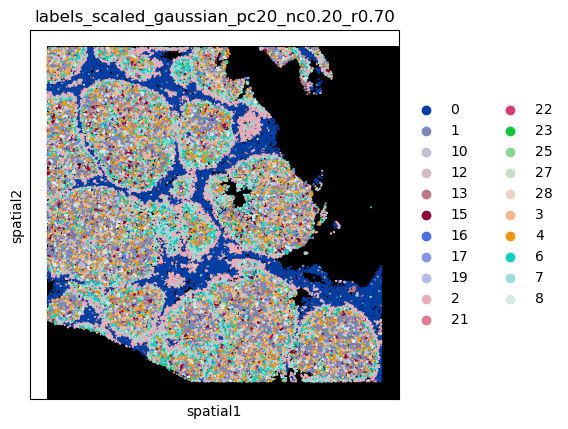

In [39]:
sc.pl.spatial(adata_sc_g_filt, color = 'labels_scaled_gaussian_pc20_nc0.20_r0.70')

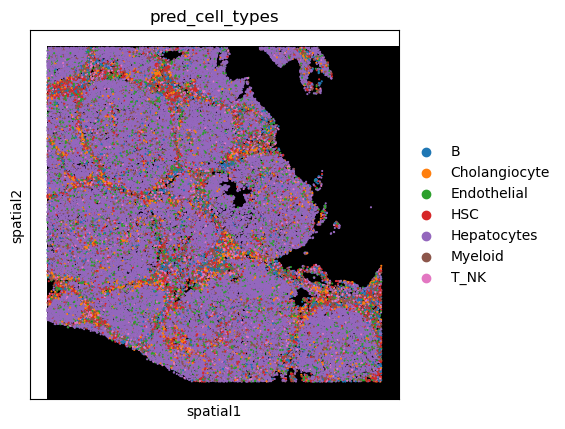

In [40]:
sc.pl.spatial(adata_sc_g_filt, color = 'pred_cell_types')

### Cell-type composition per Banksy cluster (stacked bar chart)

Displayed inline (`plt.show()`); not saved to a file, unlike the plots above -- add a `plt.savefig(...)` call here if a saved copy is wanted.

/tmp/ipykernel_253924/967865537.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df = df.groupby(['labels_scaled_gaussian_pc20_nc0.20_r0.70', 'pred_cell_types']).size().unstack(fill_value=0)


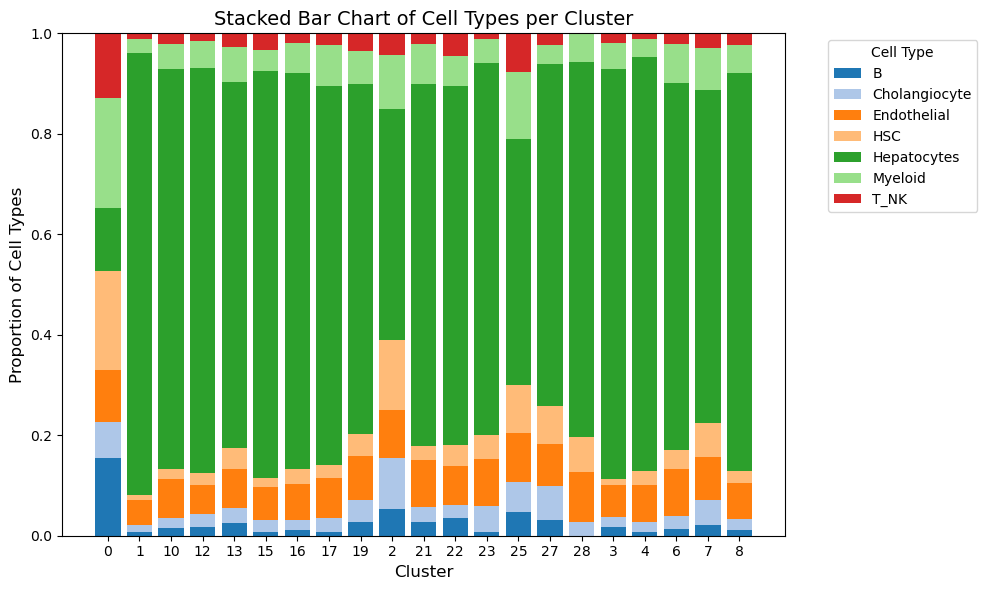

In [45]:
# Metadata columns: cluster label and predicted cell type.
df = adata_sc_g_filt.obs[['labels_scaled_gaussian_pc20_nc0.20_r0.70', 'pred_cell_types']]

# Count cells per (cluster, celltype), then normalize to proportions.
count_df = df.groupby(['labels_scaled_gaussian_pc20_nc0.20_r0.70', 'pred_cell_types']).size().unstack(fill_value=0)
proportion_df = count_df.div(count_df.sum(axis=1), axis=0)

unique_celltypes = proportion_df.columns
palette = sns.color_palette("tab20", n_colors=len(unique_celltypes))
color_dict = {celltype: palette[i] for i, celltype in enumerate(unique_celltypes)}

fig, ax = plt.subplots(figsize=(10, 6))
bottom = None
for celltype in unique_celltypes:
    ax.bar(
        proportion_df.index,
        proportion_df[celltype],
        label=celltype,
        color=color_dict[celltype],
        bottom=bottom,
    )
    if bottom is None:
        bottom = proportion_df[celltype].copy()
    else:
        bottom += proportion_df[celltype]

ax.set_title('Stacked Bar Chart of Cell Types per Cluster', fontsize=14)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Proportion of Cell Types', fontsize=12)
ax.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [46]:
adata_sc_g_filt.write_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tmp_nl_png/adata_scaled_gaussian_celltypes.h5ad')


## Marker genes for clusters of interest

Cluster 2 might be the interesting senescent population (or clusters 6, 7).

In [48]:
print(adata_sc_g_filt.obs['labels_scaled_gaussian_pc20_nc0.20_r0.70'].value_counts(dropna=False))


labels_scaled_gaussian_pc20_nc0.20_r0.70
0     11795
1     11129
3     10049
2      9538
4      8005
6      7557
7      7465
8      3827
10     3733
12     2444
13     2027
15     2003
16     1983
17     1078
19      936
21      640
22      526
23      275
25      167
27      132
28       71
Name: count, dtype: int64


In [49]:
adata_sc_g_filt_outline = adata_sc_g_filt[adata_sc_g_filt.obs['labels_scaled_gaussian_pc20_nc0.20_r0.70'].isin(['2', '6', '7'])]


In [50]:
adata_sc_g_filt_outline


View of AnnData object with n_obs × n_vars = 24560 × 6000
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'labels_scaled_gaussian_pc20_nc0.20_r0.70', 'pred_cell_types'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'is_nbr', 'k'
    uns: 'rank_genes_groups', 'spatial', 'labels_scaled_gaussian_pc20_nc0.20_r0.70_colors', 'pred_cell_types_colors'
    obsm: 'reduced_pc_20', 'reduced_pc_20_umap', 'spatial'

In [54]:
sc.tl.rank_genes_groups(adata_sc_g_filt_outline, groupby="labels_scaled_gaussian_pc20_nc0.20_r0.70", use_raw=False)
markers_df = pd.DataFrame(adata_sc_g_filt_outline.uns["rank_genes_groups"]["names"]).iloc[0:100, :]
markers = list(np.unique(markers_df.melt().value.values))
len(markers)


/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


291

In [58]:
markers_df  # seems like cluster 2 is mostly NPCs


,2,6,7
0,igkc_nbr_0,cyp2e1_nbr_0,mt2a_nbr_0
1,igfbp7_nbr_0,mt2a_nbr_0,cyp2e1_nbr_0
2,ighg1_nbr_0,ifitm3_nbr_0,mt-nd2_nbr_0
3,igkc_nbr_1,mt-nd2_nbr_0,ifitm3_nbr_0
4,ighg1_nbr_1,cyp2e1,mt2a
5,cd74_nbr_0,lhx3_nbr_1,cyp2e1
6,c7_nbr_0,mt-nd2,tmem217_nbr_0
7,igkc,tmcc3_nbr_1,uhrf1_nbr_1
8,vim_nbr_0,lhx3_nbr_0,mt-nd2
9,igha1_nbr_1,ifitm3,tmem217_nbr_1


### Spatial preview of individual marker genes

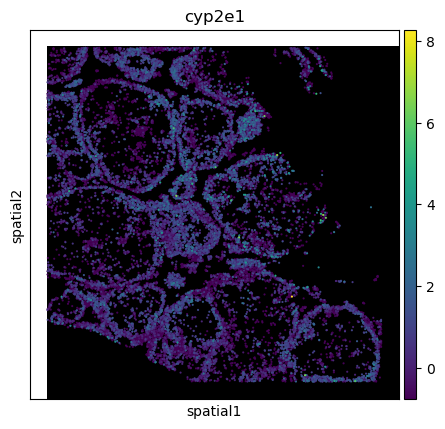

In [65]:
sc.pl.spatial(adata_sc_g_filt_outline, color = 'cyp2e1')

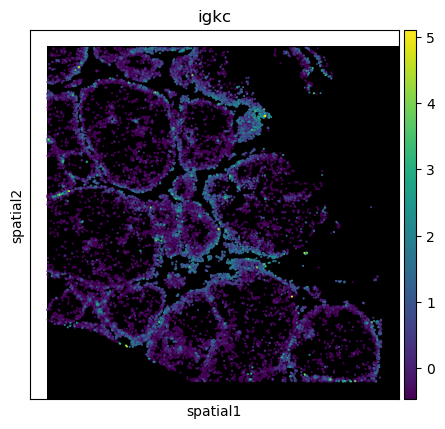

In [66]:
sc.pl.spatial(adata_sc_g_filt_outline, color = 'igkc')

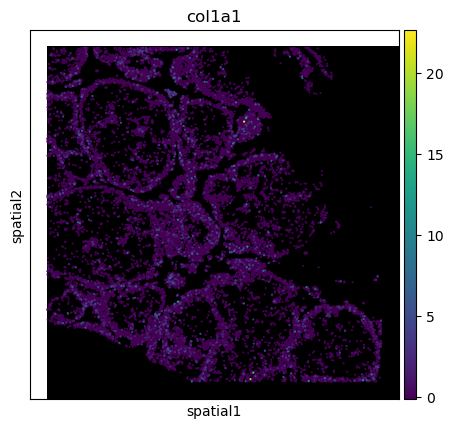

In [67]:
sc.pl.spatial(adata_sc_g_filt_outline, color = 'col1a1')

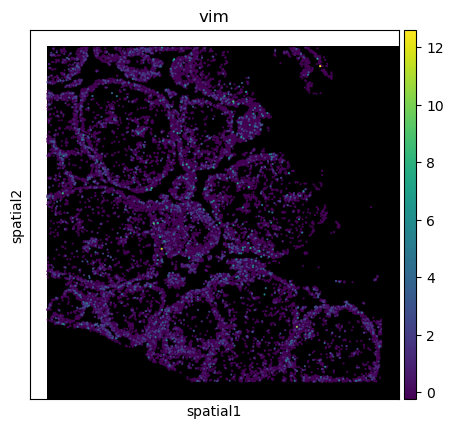

In [68]:
sc.pl.spatial(adata_sc_g_filt_outline, color = 'vim')

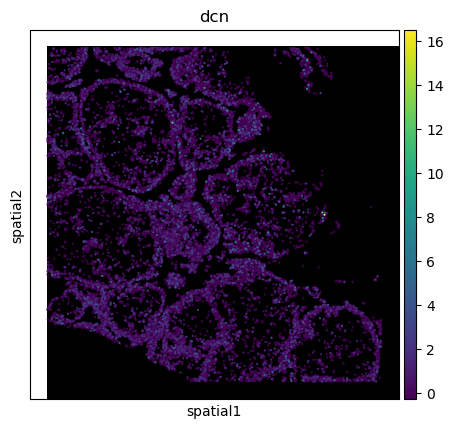

In [69]:
sc.pl.spatial(adata_sc_g_filt_outline, color = 'dcn')

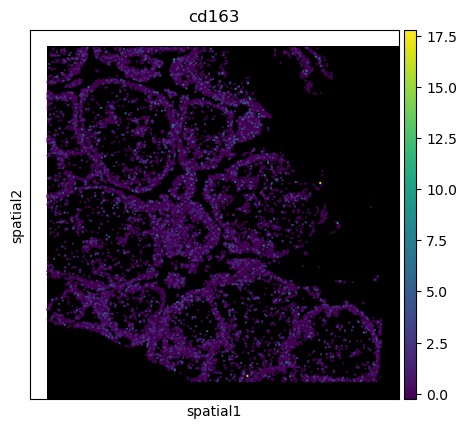

In [72]:
sc.pl.spatial(adata_sc_g_filt_outline, color = 'cd163')

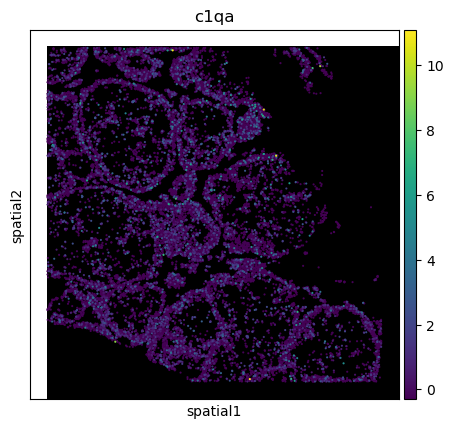

In [74]:
sc.pl.spatial(adata_sc_g_filt_outline, color = 'c1qa')

In [62]:
# Gene names in this object are lowercase (hence e.g. 'cyp2e1' above, not 'CYP2E1').
adata_sc_g_filt_outline.var_names


Index(['aanat', 'abra', 'abraxas1', 'ac008687.4', 'ac010255.3', 'ac072022.2',
       'ac090360.1', 'ac091057.6', 'ac135068.1', 'ackr1',
       ...
       'znf831_nbr_1', 'znf850_nbr_1', 'znf883_nbr_1', 'znf98_nbr_1',
       'zp4_nbr_1', 'zscan10_nbr_1', 'zscan12_nbr_1', 'zscan23_nbr_1',
       'zscan4_nbr_1', 'zswim2_nbr_1'],
      dtype='object', length=6000)